In [ ]:
import pandas as pd
import random
import matplotlib.pyplot as plt
import numpy as np

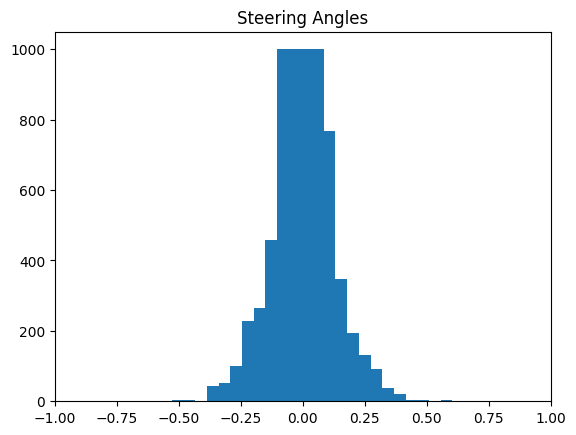

In [15]:

df = pd.read_csv("../dataset/driving_log.csv", header=None)


bin_size = 1000
bins = 35

_, bin_edges = np.histogram(df[3], bins=bins)

extra_vals = []
for i in range(bins):
	left = bin_edges[i]
	right = bin_edges[i+1]

	bin_vals = []
	for j, row in df.iterrows():

		# if inside the bin
		if row[3] >= left and row[3] < right:
			bin_vals.append(j)

	if len(bin_vals) > bin_size:
		leftover = len(bin_vals) - bin_size
		drop = random.sample(bin_vals, leftover)
		
		extra_vals.extend(drop)

# delete and fixes index
df = df.drop(extra_vals).reset_index(drop=True)

plt.hist(df[3], bins=35)
plt.xlim(-1.0, 1.0)  
plt.title("Steering Angles")

plt.show()